# 逻辑回归：把线性模型搬到分类

**课程 0004 配套练习** · 运行内核：`deeplearning`

前置：课程 0003（线性回归三件套）。本课目标：亲手实现逻辑回归，并理解它为什么能用于分类、
以及它为什么是「单层神经网络」。

回忆三要素（李航）：
- **模型**：候选函数集合
- **策略**：判断好坏的标准（损失函数）
- **算法**：怎么搜（求解方法）

每实现一步，都问自己：**我现在填的是三要素里的哪一格？**


## 问题设定

二分类：每个样本有 2 个特征，标签 `y ∈ {0, 1}`。

我们用两个稍微重叠的高斯团生成数据：类 0 在左下，类 1 在右上。


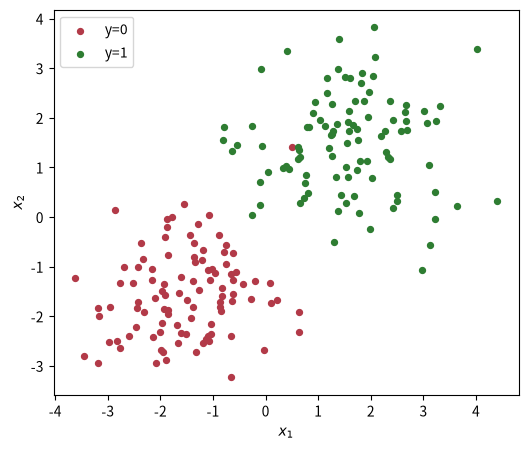

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体（避免图上中文显示为方块/警告）
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(42)
N = 200
X0 = rng.normal(loc=[-1.5, -1.5], scale=1.0, size=(N // 2, 2))
X1 = rng.normal(loc=[1.5, 1.5], scale=1.0, size=(N - N // 2, 2))
X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(N // 2), np.ones(N - N // 2)])
# 构造二分类人工数据集：两个高斯簇，左下簇标 0、右上簇标 1，用于测试逻辑回归、SVM、聚类等分类算法。

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=18, label="y=0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=18, label="y=1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.show()

## 三要素之「模型」：sigmoid 压到概率

线性回归输出是整个实数轴，而「P(y=1|x)」必须落在 (0,1)。于是我们给线性函数套一层 **sigmoid**：

$$\hat y = \sigma(w^\top x + b) = \frac{1}{1 + e^{-(w^\top x + b)}}$$

- 输出解释为 $P(y=1\mid x)$：接近 0 → 判为类 0；接近 1 → 判为类 1；0.5 是分界线。
- **模型** = 所有形如 σ(wᵀx+b) 的函数集合。分界线永远是一条直线（超平面）。


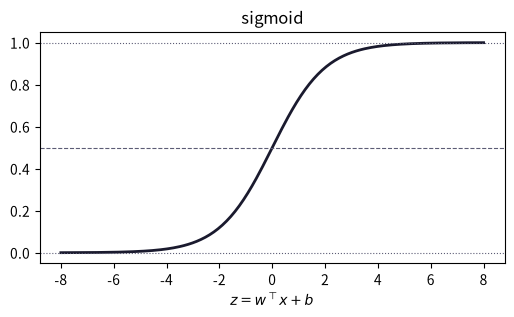

In [4]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """数值稳定版：z 很小时 exp 会溢出，先 clip。"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 3))
plt.plot(z, sigmoid(z), color="#1a1a2e", linewidth=2)
plt.axhline(0.5, ls="--", color="#5c5c75", lw=0.8); plt.axhline(0, ls=":", color="#5c5c75", lw=0.8); plt.axhline(1, ls=":", color="#5c5c75", lw=0.8)
plt.title("sigmoid"); plt.xlabel("$z = w^\\top x + b$"); plt.show()

## 为什么线性回归不能直接做分类

- 回归输出可以小于 0 或大于 1，没法当概率用。
- 一个远离集群的离群点会把回归直线整体拉偏，分类面就歪了。
- sigmoid 的意义：**输出范围固定到 (0,1)，且越接近边界越「确定」**。

> 一句话：回归管「值」，分类管「概率」。逻辑回归 = 线性函数 + sigmoid + 交叉熵。


## 三要素之「策略」：极大似然 → 交叉熵

把 $\hat y$ 当作「正类概率」，假设每个样本独立，写出**似然函数**并取负对数（负对数似然），
得到交叉熵损失（也叫对数损失、log loss）：

$$L(w) = -\frac{1}{N}\sum_i \left[ y_i \log \hat y_i + (1-y_i) \log(1-\hat y_i) \right]$$

- 含义：预测与真实标签「分布」差多远；完全对时 L=0。
- 为什么不用均方误差？sigmoid + MSE 是非凸的（有多个局部极小），而 **sigmoid + 交叉熵是凸的**，梯度下降保证收敛到全局最优。


In [5]:
def log_loss(w: np.ndarray, Xb: np.ndarray, y: np.ndarray) -> float:
    """Xb 已含常数项列。加 1e-12 防止 log(0)。"""
    yhat = sigmoid(Xb @ w)
    return float(-np.mean(y * np.log(yhat + 1e-12) + (1 - y) * np.log(1 - yhat + 1e-12)))

Xb = np.hstack([X, np.ones((N, 1))])   # 模型：ŷ = σ(Xb @ w)，w 最后一维是 b
w0 = np.zeros(len(Xb[0]))  # 初始权重全为 0，预测概率全为 0.5
print("初始损失（全部概率=0.5）：", round(log_loss(w0, Xb, y), 4), "（应为约 0.693 = ln 2）")

初始损失（全部概率=0.5）： 0.6931 （应为约 0.693 = ln 2）


## 三要素之「算法」：梯度下降

交叉熵对 w 的梯度，和线性回归的梯度**长得一模一样**：

$$\nabla_w L = \frac{1}{N} X^\top(\hat y - y)$$

（形式上只差个常数因子——都是「残差 × 特征」的平均。这就是同一个算法服务不同模型的例子。）


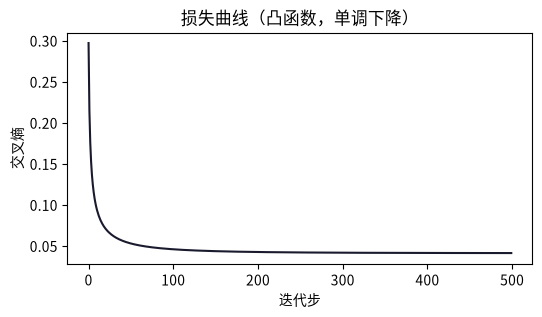

w = [2.41  2.563 0.297]
训练集准确率： 0.99


In [6]:
def train_logistic(Xb: np.ndarray, y: np.ndarray, lr: float = 0.5, steps: int = 500):
    """梯度下降。返回最终 w 与损失历史。"""
    w = np.zeros(Xb.shape[1])
    losses = []
    for _ in range(steps):
        yhat = sigmoid(Xb @ w)
        grad = (Xb.T @ (yhat - y)) / Xb.shape[0]
        w -= lr * grad
        losses.append(log_loss(w, Xb, y))
    return w, losses

w_hat, losses = train_logistic(Xb, y)

plt.figure(figsize=(6, 3))
plt.plot(losses, color="#1a1a2e", linewidth=1.5)
plt.xlabel("迭代步"); plt.ylabel("交叉熵"); plt.title("损失曲线（凸函数，单调下降）"); plt.show()
print("w =", np.round(w_hat, 3))

acc = float(np.mean((sigmoid(Xb @ w_hat) > 0.5) == y))
print("训练集准确率：", round(acc, 3))

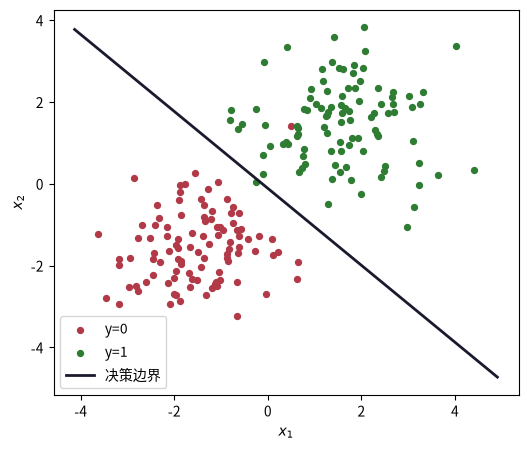

In [7]:
# 画决策边界：w·x + b = 0 是一条直线
w1, w2, b = w_hat
x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2 = -(w1 * x1 + b) / w2

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=18, label="y=0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=18, label="y=1")
plt.plot(x1, x2, color="#1a1a2e", linewidth=2, label="决策边界")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.show()

## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 损失曲线为什么单调下降、没有波动？如果学习率 lr 设成 10 会发生什么？试试并把现象写下来。

**S2.** 把边界方程 $w_1 x_1 + w_2 x_2 + b = 0$ 代入你训练出的 w，核对手绘的边界是否正确（斜率和截距）。

**M1.** 把数据划分成 train / test（前 70% / 后 30%），重新训练，报告测试集准确率。训练集准确率高而测试集准确率低，说明什么？

**M2.** 生成线性不可分数据（如以原点为圆心的同心圆：内圈 y=0，外圈 y=1），训练逻辑回归并画边界。观察准确率，并解释为什么逻辑回归对此无能为力——「模型」限制在哪？

**H1.** 把 `sigmoid` 换成不稳定的 `1/(1+np.exp(-z))`，当 z 取到 -1000 时会发生什么？（提示：exp 溢出成 inf/nan）。在哪儿会用到「稳定版」？

**H2.** 实现带 L2 正则化的逻辑回归：损失 $L + \lambda\|w\|^2$（梯度记得加上 $2\lambda w$，通常不惩罚偏置 b）。在数据重叠很严重时（把 scale 调大），对比有无正则化的测试准确率。


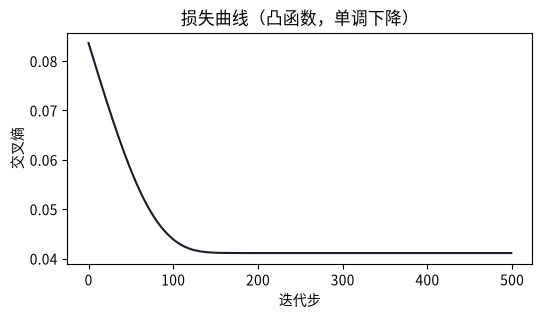

w = [2.585 2.644 0.359]
训练集准确率： 0.99


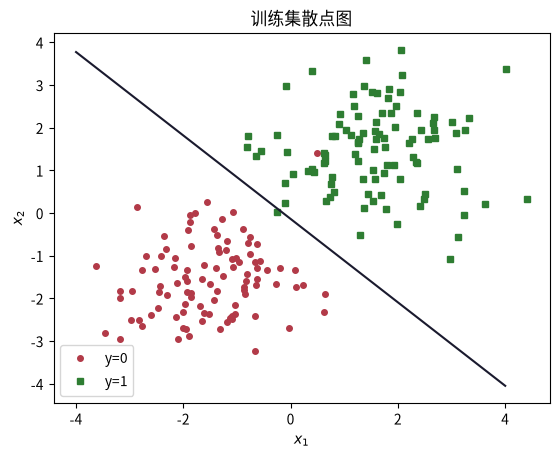

In [21]:
# pass  # 练习区（S1/S2）：在这里写实验、加 cell
def train_logistic(Xb: np.ndarray, y: np.ndarray, lr: float = 0.5, steps: int = 500):
    """梯度下降。返回最终 w 与损失历史。"""
    w = np.zeros(Xb.shape[1])
    losses = []
    for _ in range(steps):
        yhat = sigmoid(Xb @ w)
        grad = (Xb.T @ (yhat - y)) / Xb.shape[0]
        w -= lr * grad
        losses.append(log_loss(w, Xb, y))
    return w, losses

w_hat, losses = train_logistic(Xb, y, lr = 10)

plt.figure(figsize=(6, 3))
plt.plot(losses, color="#1a1a2e", linewidth=1.5)
plt.xlabel("迭代步"); plt.ylabel("交叉熵"); plt.title("损失曲线（凸函数，单调下降）"); plt.show()
print("w =", np.round(w_hat, 3))

acc = float(np.mean((sigmoid(Xb @ w_hat) > 0.5) == y))
print("训练集准确率：", round(acc, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "o", c="#b23a48", markersize=4, label="y=0")
plt.plot(X[y == 1, 0], X[y == 1, 1], "s", c="#2e7d32", markersize=4, label="y=1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.title("训练集散点图")
# plt.plot([-4, 4], [-(w_hat[0] * -4 + w_hat[2]) / w_hat[1], -(w_hat[0] * 4 + w_hat[2]) / w_hat[1]], color="#1a1a2e", linewidth=1.5, label="决策边界")
x1 = np.linspace(-4, 4, 100)
plt.plot(x1, -(w_hat[0] * x1 + w_hat[2]) / w_hat[1], color="#1a1a2e", linewidth=1.5, label="决策边界")
plt.show()

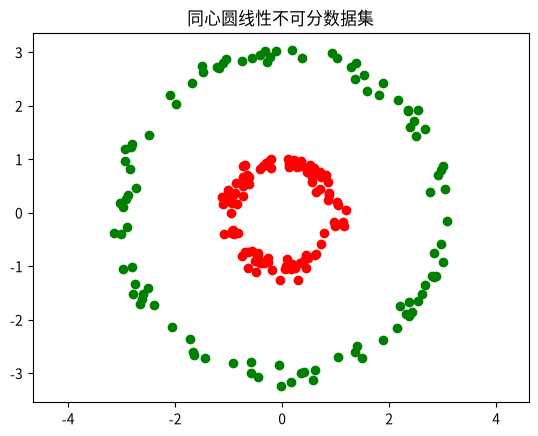

同心圆数据集逻辑回归准确率：56.50%


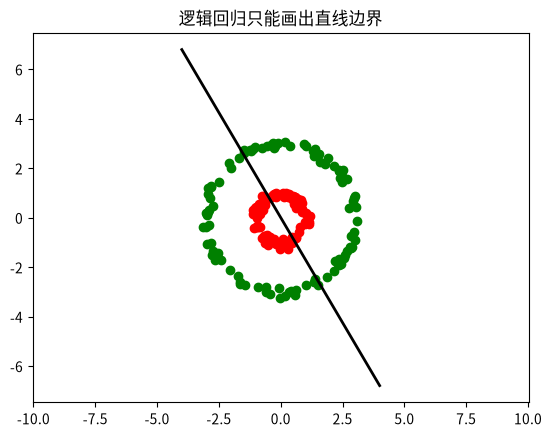

In [29]:
# pass  # 练习区（M1/M2）
def make_circle_data(n=200):
    rng = np.random.default_rng(42)
    theta = rng.uniform(0, 2*np.pi, n)
    # 内圈小圆 y=0，外圈大圆 y=1
    r0 = rng.normal(1, 0.1, n//2)
    r1 = rng.normal(3, 0.1, n//2)
    x0 = np.column_stack([r0*np.cos(theta[:n//2]), r0*np.sin(theta[:n//2])])
    x1 = np.column_stack([r1*np.cos(theta[n//2:]), r1*np.sin(theta[n//2:])])
    X_circle = np.vstack([x0, x1])
    y_circle = np.concatenate([np.zeros(n//2), np.ones(n//2)])
    return X_circle, y_circle

# 测试 lr=0.5（正常）
def train(Xb, y, lr, epochs=5000):
    w = np.zeros(3)
    loss_hist = []
    for _ in range(epochs):
        # dw = grad_loss(w, Xb, y)
        dw = (Xb.T @ (sigmoid(Xb @ w) - y)) / Xb.shape[0]
        w -= lr * dw
        # loss_hist.append(cross_entropy_loss(w, Xb, y))
        loss_hist.append(log_loss(w, Xb, y))
    return w, loss_hist

calc_acc = lambda w, Xb, y: float(np.mean((sigmoid(Xb @ w) > 0.5) == y))

X_c, y_c = make_circle_data(200)

# 先画原始数据
plt.figure()
plt.scatter(X_c[y_c==0,0], X_c[y_c==0,1], c="red")
plt.scatter(X_c[y_c==1,0], X_c[y_c==1,1], c="green")
plt.title("同心圆线性不可分数据集")
plt.axis("equal")
plt.show()

Xb_c = np.hstack([X_c, np.ones((200,1))])
w_c, _ = train(Xb_c, y_c, lr=0.5)
acc_c = calc_acc(w_c, Xb_c, y_c)
print(f"同心圆数据集逻辑回归准确率：{acc_c:.2%}")

# 画直线决策边界
plt.figure()
plt.scatter(X_c[y_c==0,0], X_c[y_c==0,1], c="red")
plt.scatter(X_c[y_c==1,0], X_c[y_c==1,1], c="green")
w0,w1,b = w_c
x1 = np.linspace(-4,4,200)
x2 = -(w0*x1 + b)/w1
plt.plot(x1, x2, c="black", lw=2)
plt.axis("equal")
plt.title("逻辑回归只能画出直线边界")
plt.show()

In [27]:
# pass  # 练习区（H1/H2）
def grad_loss_L2(w, X, y, lam=0.1):
    N = len(y)
    z = X @ w
    y_hat = sigmoid(z)
    grad_ce = X.T @ (y_hat - y) / N
    # 只对前两个权重加L2梯度，偏置w[2]不加
    reg_grad = np.array([lam * w[0], lam * w[1], 0.0])      # 这里是一个行向量
    return grad_ce + reg_grad

def train_L2(Xb, y, lr=0.5, lam=0.1, epochs=5000):
    w = np.zeros(3)
    for _ in range(epochs):
        dw = grad_loss_L2(w, Xb, y, lam)
        w -= lr * dw
    return w

# 计算准确率函数
def calc_acc(w, Xb, y):
    z = Xb @ w
    y_pred = (sigmoid(z) > 0.5).astype(int)
    return np.mean(y_pred == y)

# 放大数据噪声 scale=2.0，制造严重重叠
rng = np.random.default_rng(42)
N=200
X0_noise = rng.normal([-1.5,-1.5], scale=2.0, size=(100,2))
X1_noise = rng.normal([1.5,1.5], scale=2.0, size=(100,2))
X_noise = np.vstack([X0_noise, X1_noise])
y_noise = np.concatenate([np.zeros(100), np.ones(100)])

# 划分7:3数据集
sp = int(0.7*200)
Xtr, Xte = X_noise[:sp], X_noise[sp:]
ytr, yte = y_noise[:sp], y_noise[sp:]
Xb_tr = np.hstack([Xtr, np.ones((sp,1))])
Xb_te = np.hstack([Xte, np.ones((60,1))])

# 1. 无正则 lam=0
w_no_reg = train_L2(Xb_tr, ytr, lam=0)
acc_tr1 = calc_acc(w_no_reg, Xb_tr, ytr)
acc_te1 = calc_acc(w_no_reg, Xb_te, yte)

# 2. 带L2正则 lam=0.5
w_reg = train_L2(Xb_tr, ytr, lam=0.05)
acc_tr2 = calc_acc(w_reg, Xb_tr, ytr)
acc_te2 = calc_acc(w_reg, Xb_te, yte)

print("=== 无L2正则 ===")
print(f"训练集{acc_tr1:.2%} 测试集{acc_te1:.2%}")
print("=== 带L2正则 ===")
print(f"训练集{acc_tr2:.2%} 测试集{acc_te2:.2%}")

=== 无L2正则 ===
训练集90.71% 测试集73.33%
=== 带L2正则 ===
训练集90.00% 测试集73.33%


## 与神经网络的衔接

逻辑回归 = **单个神经元**：输入 → 线性加权 → sigmoid 激活 → 交叉熵。

- 多分类版：最后一层换 **softmax** + 分类交叉熵——你的 MLP 输出层就是这个。
- 你之前学的 MLP（FashionMNIST 那课）就是「很多个逻辑回归 + 中间的非线性层」叠起来。

下一课：**k 近邻与朴素贝叶斯**——两个「不需要训练」的直觉型分类器，回头反衬逻辑回归的假设。
